# **Proyecto Integrador**
# ***LUMINA* - La Biblia Viva con IA**

Plataforma conversacional que facilita la comprensión y aplicación contextual del texto bíblico mediante NLP y RAG, con un enfoque responsable, trazable y centrado en el usuario.

---

> *"Y será predicado este evangelio del reino en todo el mundo, por testimonio a todos los Gentiles; y entonces vendrá el fin".*
>
> — Mateo 24:14

---

### **Avance 5 - Modelo final**
**Equipo:** *#19*  
**Curso:** *Proyecto Integrador*  
**Posgrado:** *MNA - Maestría en Inteligencia Artificial Aplicada*  
**Institución:** Tecnológico de Monterrey  
**Fecha:** *01 de marzo del 2026*  

---

### **Miembros del equipo**
- **A01732505** - Steven Sebastian Brutscher Cortez
- **A01795323** - Anghelo Daniel Pérez Martínez
- **A01423059** - Esmeralda González García

---
> *Este notebook corresponde al **Avance 5: Modelo final** del curso Proyecto Integrador de la Maestría en Inteligencia Artificial Aplicada (MNA) del Tecnológico de Monterrey*

De acuerdo con **CRISP-ML(Q)**, este trabajo se ubica principalmente en la fase de **Modeling (Modelado)** y parcialmente en **Evaluation (Evaluación)**.

En esta etapa no solo se selecciona un modelo individual óptimo, sino que se diseñan estrategias de combinación (ensambles) que permitan:

- Aprovechar fortalezas complementarias,
- Mitigar debilidades individuales,
- Mejorar robustez,
- Reducir riesgo de alucinaciones,
- Maximizar desempeño bajo criterios trazables.

Asimismo, esta fase conecta con el principio de calidad de CRISP-ML(Q) al incorporar validación rigurosa en datos no vistos, medición de tiempos, análisis comparativo y documentación reproducible del modelo final seleccionado.


---

> *"Porque somos hechura suya, criados en Cristo Jesús para buenas obras, las cuales Dios preparó para que anduviésemos en ellas".*
>
> — Efesios 2:10

---

# **Introducción**

En el Avance 4 se identificó el modelo individual de mejor desempeño para el sistema LUMINA, mediante evaluación estricta con verificación explícita de grounding y penalización de citation leakage.

Sin embargo, los modelos individuales poseen limitaciones inherentes. Aunque uno pueda superar a los demás en promedio, distintos modelos pueden capturar matices complementarios del problema:

- Algunos recuperan mejor contexto semántico.
- Otros presentan menor variabilidad generativa.
- Algunos muestran menor leakage bajo ciertas categorías de consulta.

Por ello, el presente avance busca diseñar y evaluar **modelos de ensamble**, tanto homogéneos como heterogéneos, que integren las fortalezas de los modelos individuales previamente seleccionados.

El objetivo no es únicamente mejorar una métrica, sino aumentar la robustez del sistema bajo criterios estrictos de fidelidad bíblica, trazabilidad y consistencia pastoral.

# **Objetivos de aprendizaje**

Al finalizar este avance se espera:

1. Diseñar ensambles homogéneos y heterogéneos aplicados a un sistema RAG generativo.
2. Implementar estrategias de voting, blending y stacking adaptadas a modelos generativos.
3. Evaluar ensambles bajo métricas estrictas de grounding.
4. Comparar modelos individuales vs ensambles bajo métricas cuantitativas y tiempos de ejecución.
5. Seleccionar un modelo final alineado con objetivos técnicos y necesidades del negocio (LUMINA).

# **Relación con el Avance 4 – Modelos Alternativos**

En el Avance 4 se:

- Construyeron 6 modelos individuales.
- Implementó evaluación STRICT con penalización por leakage.
- Se realizó ajuste fino reducido.
- Se seleccionó el mejor modelo individual.

El modelo ganador fue:

**M5_DENSE_OAI_RAG**
- k = 1
- temperature = 0.0
- context_max_chars = 3500

Este modelo sirve ahora como base para la construcción de ensambles.

En esta fase no se re-optimiza desde cero, sino que se aprovechan los modelos individuales de mejor rendimiento para construir combinaciones más robustas.

# **Conexión con CRISP-ML(Q)**

Este avance fortalece las dimensiones de calidad propuestas por CRISP-ML(Q):

- **Robustez:** al combinar modelos para reducir variabilidad.
- **Fiabilidad:** al mantener evaluación estricta con verificación de grounding.
- **Reproducibilidad:** al documentar configuraciones y resultados.
- **Transparencia:** al comparar explícitamente modelos individuales y ensambles.
- **Eficiencia:** al incluir tiempos de ejecución en la comparación final.

El uso de ensambles permite mitigar riesgos asociados a decisiones dependientes de un único modelo, alineándose con principios de ingeniería responsable en sistemas de IA.

# **Recordatorio – Modelo Individual Ganador (Avance 4)**

El modelo individual con mejor desempeño fue:

**M5_DENSE_OAI_RAG**

Configuración final:
- Retriever: Dense con embeddings OpenAI
- k = 1
- temperature = 0.0
- context_max_chars = 3500

Desempeño en evaluación STRICT (30 queries):
- judge_overall_adj_mean ≈ 4.64
- leakage_rate_mean ≈ 0.43
- Mejor balance entre fidelidad, relevancia y control de citas fuera de contexto.

Este modelo servirá como punto de referencia base para evaluar los ensambles construidos en esta fase.

---

> *"Y dijo Dios: "¡Que sea la luz!", y fue la luz".*
>
> — Génesis 1:3

---

## **Setup inicial: rutas, artefactos y núcleo reutilizable (lumina_core)**

En esta sección se prepara el entorno de ejecución y se establecen rutas explícitas a todos los insumos del proyecto (parquet, embeddings, manifest y conjunto de evaluación). Posteriormente, se cargan y validan los artefactos principales:

- `df_chunks` desde `.parquet` (chunks bíblicos y metadatos)
- `embeddings` desde `.npz` (representaciones vectoriales normalizadas)
- `manifest` desde `.json` (modelo de embeddings y configuración)

Finalmente, para mantener **consistencia total con el Avance 4** sin copiar/pegar cientos de líneas en este notebook, se importa e inicializa el módulo `lumina_core.py`, que encapsula:
retrievers (BM25/Dense/Hybrid), reranker, runners (incluyendo tuning y M5 OpenAI), y evaluación STRICT con penalización por leakage.

In [6]:
# ============================================================
# Montando Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# ==========================================
# Definiendo el BASE_PATH
# ==========================================

from pathlib import Path
BASE_PATH = Path("/content/drive/MyDrive/Maestría ITESM/LUMINA - Proyecto Integrador/Avance 5 - Modelo final/")
print(BASE_PATH)
print("Existe:", BASE_PATH.exists())

/content/drive/MyDrive/Maestría ITESM/LUMINA - Proyecto Integrador/Avance 5 - Modelo final
Existe: True


In [8]:
# ==========================================
# Otras rutas
# ==========================================

import json
import numpy as np
import pandas as pd
import time

PARQUET_PATH = BASE_PATH / "lumina_chunks_tabular_20260207_084138.parquet"
EMB_PATH = BASE_PATH / "lumina_embeddings_20260207_084138.npz"
MANIFEST_PATH = BASE_PATH / "embedding_manifest_20260207_084138.json"
EVAL_JSON_PATH = BASE_PATH / "lumina_eval_set_v1.json"
EVAL_CSV_PATH = BASE_PATH / "lumina_eval_set_v1.csv"

print("Rutas definidas correctamente:")
print(PARQUET_PATH)
print(EMB_PATH)
print(EVAL_JSON_PATH)

Rutas definidas correctamente:
/content/drive/MyDrive/Maestría ITESM/LUMINA - Proyecto Integrador/Avance 5 - Modelo final/lumina_chunks_tabular_20260207_084138.parquet
/content/drive/MyDrive/Maestría ITESM/LUMINA - Proyecto Integrador/Avance 5 - Modelo final/lumina_embeddings_20260207_084138.npz
/content/drive/MyDrive/Maestría ITESM/LUMINA - Proyecto Integrador/Avance 5 - Modelo final/lumina_eval_set_v1.json


In [9]:
# ==========================================
# Cargar artefactos + definir columnas clave
# ==========================================

ID_COL = "chunk_id"
REF_COL = "chunk_ref"
TEXT_COL = "chunk_text_rv1909"
EMB_KEY = "emb_rv1909"

# Parquet
t0 = time.time()
df_chunks = pd.read_parquet(PARQUET_PATH)
print("Parquet cargado:", df_chunks.shape, f"({time.time()-t0:.2f}s)")

# NPZ embeddings
t0 = time.time()
npz = np.load(EMB_PATH, allow_pickle=True)
print("Keys NPZ:", npz.files, f"({time.time()-t0:.2f}s)")

npz_chunk_ids = npz[ID_COL]
embeddings = npz[EMB_KEY]

print("Embeddings:", embeddings.shape)

# Validaciones mínimas
assert df_chunks.shape[0] == embeddings.shape[0], "Mismatch filas parquet vs embeddings"
assert np.array_equal(df_chunks[ID_COL].values, npz_chunk_ids), "chunk_id no alineado entre parquet y npz"

# Manifest
with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
    manifest = json.load(f)

print("Manifest:", manifest)

Parquet cargado: (10058, 29) (1.88s)
Keys NPZ: ['chunk_id', 'emb_rv1909', 'emb_vbl'] (1.47s)
Embeddings: (10058, 384)
Manifest: {'model': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', 'normalized': True, 'n_chunks': 10058, 'created_at': '20260207_084138'}


In [10]:
# ==========================================
# Importando módulo lumina_core y construcción de Core
# ==========================================

!pip -q install rank_bm25

from __future__ import annotations

import os
import re
import hashlib
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Tuple, Optional

import sys
sys.path.append(str(BASE_PATH))

from lumina_core import LuminaCore, apply_leakage_penalty

core = LuminaCore(
    base_path=BASE_PATH,
    df_chunks=df_chunks,
    embeddings=embeddings,
    manifest=manifest,
    id_col=ID_COL,
    ref_col=REF_COL,
    text_col=TEXT_COL,
    emb_key=EMB_KEY,
    gen_model_name="gpt-4o-mini",
)

core.init_all(openai_api_key=os.environ.get("OPENAI_API_KEY", None))
print("Core listo. Modelos:", list(core.MODELS.keys()))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Core listo. Modelos: ['M1_LLM_ONLY', 'M2_BM25_RAG', 'M3_DENSE_ST_RAG', 'M4_HYBRID_RAG', 'M5_DENSE_OAI_RAG', 'M6_DENSE_ST_RERANK']


### Interpretación

Los artefactos fueron cargados correctamente y se confirmó consistencia entre el `.parquet` y el `.npz` (mismo número de chunks y alineación exacta por `chunk_id`).

El `manifest` valida que los embeddings locales corresponden al modelo indicado y que se generaron en la fecha esperada.

Asimismo, el núcleo `LuminaCore` quedó inicializado con éxito, incluyendo:
- Índice BM25
- Modelo SentenceTransformers (para embeddings de query)
- Cross-Encoder (para reranking)
- Definición formal de los seis modelos alternativos (M1–M6)

Con esto, el notebook queda listo para construir y evaluar ensambles sobre los **mejores modelos individuales** obtenidos en el Avance 4, asegurando trazabilidad y comparabilidad de resultados.

---

> *"Pero que todo se haga decentemente y con orden."*
>
> — 1 Corintios 14:40

---

# **PARTE 1 – Definición formal de ensambles**

Un ensamble es una estrategia que combina múltiples modelos con el objetivo de:

- Reducir error promedio.
- Disminuir varianza.
- Mejorar robustez ante distintos tipos de consulta.
- Aprovechar fortalezas complementarias.

En el contexto de LUMINA (sistema RAG generativo), los ensambles no combinan probabilidades de clasificación, sino decisiones generativas evaluadas mediante métricas estrictas.

Se implementarán cuatro tipos de ensamble:

1. **Ensamble Heterogéneo – Voting por mejor score STRICT**
2. **Ensamble Heterogéneo – Voting por menor leakage**
3. **Ensamble Heterogéneo – Blending score ponderado**
4. **Ensamble Heterogéneo con regla de Stacking basada en categoría**

Estos ensambles utilizarán como base los modelos individuales:
- M5_DENSE_OAI_RAG
- M3_DENSE_ST_RAG

---

> *"Y me buscaréis y hallaréis, porque me buscaréis de todo vuestro corazón."*
>
> — Jeremías 29:13

---

# **PARTE 2 – Ensamble 1: Voting por mejor score STRICT**

Este ensamble heterogéneo combina los dos mejores modelos individuales:

- M5_DENSE_OAI_RAG
- M3_DENSE_ST_RAG

Para cada consulta:

1. Se generan ambas respuestas.
2. Se evalúan con el esquema STRICT (incluyendo penalización por leakage).
3. Se selecciona la respuesta con mayor `overall_adjusted`.

Este enfoque permite elegir dinámicamente el modelo que mejor responde a cada consulta individual.

In [11]:
# ==========================================
# Parte 2 - Ensamble 1: Voting STRICT
# ==========================================

from lumina_core import (
    build_context,
    extract_citations,
    citations_in_context,
    apply_leakage_penalty
)

def ensemble_voting_strict(query: str, expected_refs=None, use_cache: bool = True):
    """
    Ensamble heterogéneo (M5 vs M3):
    - Ejecuta ambos modelos con la configuración final del Avance 4
    - Evalúa con STRICT + penalización por leakage
    - Devuelve la respuesta con mayor overall_adjusted
    """

    # Configuración final individual (desde Avance 4)
    k = 1
    temperature = 0.0
    context_max_chars = 3500

    # Ejecutar ambos modelos vía Core (mantiene consistencia con Avance 4)
    out_m5 = core.run_model_tuned(
        model_id="M5_DENSE_OAI_RAG",
        query=query,
        k=k,
        temperature=temperature,
        context_max_chars=context_max_chars,
        use_cache=use_cache
    )

    out_m3 = core.run_model_tuned(
        model_id="M3_DENSE_ST_RAG",
        query=query,
        k=k,
        temperature=temperature,
        context_max_chars=context_max_chars,
        use_cache=use_cache
    )

    def eval_strict(out):
        retrieved_refs = [r["chunk_ref"] for r in out["retrieved"]]
        context_str, _ = build_context(out["retrieved"], max_chars=context_max_chars)

        # Leakage: citas mencionadas en respuesta que NO están en contexto recuperado
        ans_cits = extract_citations(out["answer"])
        _, out_ctx = citations_in_context(ans_cits, retrieved_refs)

        js = core.judge_strict(
            query=query,
            answer=out["answer"],
            context_str=context_str,
            retrieved_refs=retrieved_refs,
            use_cache=True
        )
        js2 = apply_leakage_penalty(js, n_out=len(out_ctx))
        js2["leakage_out_of_context_count"] = len(out_ctx)
        return js2

    js_m5 = eval_strict(out_m5)
    js_m3 = eval_strict(out_m3)

    # Selección por mejor overall_adjusted
    if float(js_m5.get("overall_adjusted") or 0) >= float(js_m3.get("overall_adjusted") or 0):
        chosen = "M5_DENSE_OAI_RAG"
        out = out_m5
        js_final = js_m5
    else:
        chosen = "M3_DENSE_ST_RAG"
        out = out_m3
        js_final = js_m3

    return {
        "chosen_model": chosen,
        "output": out,
        "judge": js_final
    }

In [12]:
# ==========================================
# Eval set + Smoke test del Ensamble 1
# ==========================================

# Cargar CSV (estructura tabular)
df_eval = pd.read_csv(EVAL_CSV_PATH)

print("Eval set cargado.")
print("Shape:", df_eval.shape)
display(df_eval.head())

# Verificar consistencia con JSON
with open(EVAL_JSON_PATH, "r", encoding="utf-8") as f:
    eval_json = json.load(f)

print("\nNúmero de entradas en JSON:", len(eval_json))

# Smoke test con una query del eval set
sample_query = df_eval.iloc[0]["query"]

ens_out = ensemble_voting_strict(sample_query, use_cache=True)

print("\n==========================================")
print("SMOKE TEST - Ensamble 1 (Voting STRICT)")
print("==========================================")
print("Modelo elegido:", ens_out["chosen_model"])
print("Score STRICT (overall_adjusted):", ens_out["judge"].get("overall_adjusted"))
print("Leakage out-of-context count:", ens_out["judge"].get("leakage_out_of_context_count"))
print("\nRespuesta completa:\n")
print(ens_out["output"]["answer"])

Eval set cargado.
Shape: (30, 5)


,qid,category,query,expected_refs,notes
0,E01,emocional_consuele,Perdí a un familiar y siento que Dios me aband...,"['PSA 23', 'MAT 5:4', 'JHN 11', 'ROM 8:38-39']","Consuelo pastoral, validación emocional, groun..."
1,E02,emocional_consuele,Tengo ansiedad por el futuro y no puedo dormir...,"['PHP 4:6-7', 'MAT 6:25-34', 'PSA 94']","Debe orientar a oración, confianza y práctica ..."
2,E03,emocional_consuele,Siento culpa por errores del pasado y creo que...,"['1JHN 1:9', 'PSA 51', 'LUK 15']","Debe explicar gracia, arrepentimiento y restau..."
3,E04,emocional_consuele,Estoy agotado y sin motivación espiritual. ¿Qu...,"['PSA 42', 'ISA 40:29-31', 'MAT 11:28-30']","Debe normalizar sequedad espiritual, dar pasos..."
4,E05,emocional_consuele,Tengo miedo constante a la muerte. ¿Cómo habla...,"['HEB 2:14-15', 'JHN 14:1-3', '1COR 15']",Debe hablar de esperanza cristiana y vencer te...



Número de entradas en JSON: 30

SMOKE TEST - Ensamble 1 (Voting STRICT)
Modelo elegido: M5_DENSE_OAI_RAG
Score STRICT (overall_adjusted): 4.6
Leakage out-of-context count: 1

Respuesta completa:

Querido hermano o hermana en Cristo, lamento profundamente la pérdida de tu ser querido. El duelo es una experiencia dolorosa y, a menudo, puede hacernos sentir solos y abandonados. En el Salmo 42, el salmista expresa su angustia y su sensación de abandono por parte de Dios, preguntando: "¿Por qué te has olvidado de mí?" (Salmo 42:9). Es natural sentir que Dios está distante en momentos de dolor, pero es importante recordar que Él está con nosotros incluso en nuestras horas más oscuras.

La Biblia nos muestra que el duelo es una parte del proceso humano y que Dios comprende nuestro sufrimiento. Aunque el salmista se siente afligido y cuestiona la presencia de Dios, su honestidad en la oración es un recordatorio de que podemos llevar nuestras luchas y preguntas a Él. Dios no se aleja de nosotr

In [13]:
# ==========================================
# Evaluación global del Ensamble 1
# ==========================================

rows = []

for _, row in df_eval.iterrows():
    query = row["query"]

    ens = ensemble_voting_strict(query, use_cache=True)

    out = ens["output"]
    js = ens["judge"]

    # leakage booleano: depende de cómo lo guardemos en el judge
    # En nuestra versión: "leakage_penalty" debería existir si el judge STRICT lo devuelve.
    # Para robustez: usamos count > 0 si existe, si no, inferimos desde out_of_context_count.
    leakage_flag = False
    if "leakage_penalty" in js:
        leakage_flag = (js.get("leakage_penalty", 0) > 0)
    else:
        leakage_flag = (js.get("leakage_out_of_context_count", 0) > 0)

    rows.append({
        "chosen_model": ens["chosen_model"],
        "judge_overall_adj": float(js.get("overall_adjusted", np.nan)),
        "leakage": leakage_flag,
        "retrieval_time": float(out["timing"].get("retrieval_s", np.nan)),
        "generation_time": float(out["timing"].get("generation_s", np.nan)),
        "total_time": float(out["timing"].get("total_s", np.nan)),
    })

ensemble1_df = pd.DataFrame(rows)

display(ensemble1_df.head())

ensemble1_metrics = {
    "model": "ENS1_VOTING_STRICT (M5 vs M3)",
    "judge_overall_adj_mean": ensemble1_df["judge_overall_adj"].mean(),
    "leakage_rate_mean": ensemble1_df["leakage"].mean(),
    "retrieval_time_mean": ensemble1_df["retrieval_time"].mean(),
    "generation_time_mean": ensemble1_df["generation_time"].mean(),
    "total_time_mean": ensemble1_df["total_time"].mean(),
    "m5_win_rate": (ensemble1_df["chosen_model"] == "M5_DENSE_OAI_RAG").mean(),
    "m3_win_rate": (ensemble1_df["chosen_model"] == "M3_DENSE_ST_RAG").mean(),
}

ensemble1_metrics

,chosen_model,judge_overall_adj,leakage,retrieval_time,generation_time,total_time
0,M5_DENSE_OAI_RAG,4.6,True,8.231807,8.175561,16.408239
1,M5_DENSE_OAI_RAG,4.6,True,0.188812,6.943172,7.132037
2,M5_DENSE_OAI_RAG,5.0,False,2.683020,5.531649,8.214756
3,M5_DENSE_OAI_RAG,5.0,False,0.186318,7.404588,7.590959
4,M5_DENSE_OAI_RAG,4.0,True,0.179821,7.968055,8.147927


{'model': 'ENS1_VOTING_STRICT (M5 vs M3)',
 'judge_overall_adj_mean': np.float64(4.6866666666666665),
 'leakage_rate_mean': np.float64(0.3333333333333333),
 'retrieval_time_mean': np.float64(0.5142963568369547),
 'generation_time_mean': np.float64(8.830555113156636),
 'total_time_mean': np.float64(9.344933168093364),
 'm5_win_rate': np.float64(0.7666666666666667),
 'm3_win_rate': np.float64(0.23333333333333334)}

### Interpretación (Ensamble 1: Voting por mejor score STRICT)

En la evaluación global sobre el conjunto de 30 consultas, el Ensamble 1 (M5 vs M3) obtuvo un desempeño promedio alto:

- `judge_overall_adj_mean = 4.69` (escala 1–5, ya ajustado con penalización por leakage)
- `leakage_rate_mean = 0.33` (≈ 1 de cada 3 respuestas presentó al menos una cita fuera del contexto recuperado, según el detector)
- Tiempo promedio total: `≈ 9.34 s` por consulta

Además, el gating dinámico mostró que M5 fue seleccionado en la mayoría de consultas (`m5_win_rate ≈ 0.77`), mientras que M3 ganó en una fracción relevante (`m3_win_rate ≈ 0.23`). Esto sugiere que el ensamble no es un “placeholder”, sino que realmente elige el submodelo más fuerte según el caso, aportando robustez y reduciendo el riesgo de escoger un único modelo fijo para todo el dominio de preguntas.

---

> *"Llámame y te responderé; y te mostraré cosas grandes y ocultas que tú no conoces."*
>
> — Jeremías 33:3

---

## **PARTE 3 – Ensamble 2: Voting por menor leakage**

Este ensamble heterogéneo también combina los dos mejores modelos individuales (M5 y M3), pero cambia la regla de decisión:

- Se generan ambas respuestas.
- Se evalúan con el esquema STRICT (incluyendo penalización por leakage).
- Se selecciona la respuesta con **menor leakage** (menos citas fuera del contexto).
- En caso de empate (mismo leakage), se desempata por **mayor `overall_adjusted`**.

Este enfoque prioriza trazabilidad y control de alucinaciones (citation leakage), incluso si el score global es similar.

In [14]:
# ==========================================
# Parte 3 - Ensamble 2: Voting por menor leakage
# ==========================================

def ensemble_voting_min_leakage(query: str, use_cache: bool = True):
    """
    Ensamble heterogéneo (M5 vs M3):
    - Ejecuta ambos modelos con la configuración final del Avance 4
    - Evalúa con STRICT + penalización por leakage
    - Selecciona por MENOR leakage (out_of_context_count)
    - Empate: mayor overall_adjusted
    """

    k = 1
    temperature = 0.0
    context_max_chars = 3500

    out_m5 = core.run_model_tuned(
        model_id="M5_DENSE_OAI_RAG",
        query=query,
        k=k,
        temperature=temperature,
        context_max_chars=context_max_chars,
        use_cache=use_cache
    )

    out_m3 = core.run_model_tuned(
        model_id="M3_DENSE_ST_RAG",
        query=query,
        k=k,
        temperature=temperature,
        context_max_chars=context_max_chars,
        use_cache=use_cache
    )

    def eval_strict_with_leak(out):
        retrieved_refs = [r["chunk_ref"] for r in out["retrieved"]]
        context_str, _ = build_context(out["retrieved"], max_chars=context_max_chars)

        ans_cits = extract_citations(out["answer"])
        _, out_ctx = citations_in_context(ans_cits, retrieved_refs)

        js = core.judge_strict(
            query=query,
            answer=out["answer"],
            context_str=context_str,
            retrieved_refs=retrieved_refs,
            use_cache=True
        )
        js2 = apply_leakage_penalty(js, n_out=len(out_ctx))
        js2["leakage_out_of_context_count"] = len(out_ctx)
        return js2, len(out_ctx)

    js_m5, leak_m5 = eval_strict_with_leak(out_m5)
    js_m3, leak_m3 = eval_strict_with_leak(out_m3)

    # Regla: menor leakage
    if leak_m5 < leak_m3:
        chosen = "M5_DENSE_OAI_RAG"
        out = out_m5
        js_final = js_m5
    elif leak_m3 < leak_m5:
        chosen = "M3_DENSE_ST_RAG"
        out = out_m3
        js_final = js_m3
    else:
        # Empate: mayor overall_adjusted
        if float(js_m5.get("overall_adjusted") or 0) >= float(js_m3.get("overall_adjusted") or 0):
            chosen = "M5_DENSE_OAI_RAG"
            out = out_m5
            js_final = js_m5
        else:
            chosen = "M3_DENSE_ST_RAG"
            out = out_m3
            js_final = js_m3

    return {
        "chosen_model": chosen,
        "output": out,
        "judge": js_final
    }

In [15]:
# ==========================================
# Evaluación global del Ensamble 2
# ==========================================

rows = []

for _, row in df_eval.iterrows():
    query = row["query"]

    ens = ensemble_voting_min_leakage(query, use_cache=True)
    out = ens["output"]
    js = ens["judge"]

    # leakage booleano robusto
    if "leakage_penalty" in js:
        leakage_flag = (js.get("leakage_penalty", 0) > 0)
    else:
        leakage_flag = (js.get("leakage_out_of_context_count", 0) > 0)

    rows.append({
        "chosen_model": ens["chosen_model"],
        "judge_overall_adj": float(js.get("overall_adjusted", np.nan)),
        "leakage": leakage_flag,
        "retrieval_time": float(out["timing"].get("retrieval_s", np.nan)),
        "generation_time": float(out["timing"].get("generation_s", np.nan)),
        "total_time": float(out["timing"].get("total_s", np.nan)),
        "leakage_out_of_context_count": int(js.get("leakage_out_of_context_count", -1)),
    })

ensemble2_df = pd.DataFrame(rows)
display(ensemble2_df.head())

ensemble2_metrics = {
    "model": "ENS2_VOTING_MIN_LEAKAGE (M5 vs M3)",
    "judge_overall_adj_mean": ensemble2_df["judge_overall_adj"].mean(),
    "leakage_rate_mean": ensemble2_df["leakage"].mean(),
    "avg_out_of_context_cits": ensemble2_df["leakage_out_of_context_count"].replace(-1, np.nan).mean(),
    "retrieval_time_mean": ensemble2_df["retrieval_time"].mean(),
    "generation_time_mean": ensemble2_df["generation_time"].mean(),
    "total_time_mean": ensemble2_df["total_time"].mean(),
    "m5_win_rate": (ensemble2_df["chosen_model"] == "M5_DENSE_OAI_RAG").mean(),
    "m3_win_rate": (ensemble2_df["chosen_model"] == "M3_DENSE_ST_RAG").mean(),
}

ensemble2_metrics

,chosen_model,judge_overall_adj,leakage,retrieval_time,generation_time,total_time,leakage_out_of_context_count
0,M5_DENSE_OAI_RAG,4.6,True,8.231807,8.175561,16.408239,1
1,M5_DENSE_OAI_RAG,4.6,True,0.188812,6.943172,7.132037,1
2,M5_DENSE_OAI_RAG,5.0,False,2.683020,5.531649,8.214756,0
3,M5_DENSE_OAI_RAG,5.0,False,0.186318,7.404588,7.590959,0
4,M5_DENSE_OAI_RAG,4.0,True,0.179821,7.968055,8.147927,1


{'model': 'ENS2_VOTING_MIN_LEAKAGE (M5 vs M3)',
 'judge_overall_adj_mean': np.float64(4.666666666666667),
 'leakage_rate_mean': np.float64(0.3333333333333333),
 'avg_out_of_context_cits': np.float64(0.4),
 'retrieval_time_mean': np.float64(0.5248862663904826),
 'generation_time_mean': np.float64(8.737218300501505),
 'total_time_mean': np.float64(9.262186018625895),
 'm5_win_rate': np.float64(0.8333333333333334),
 'm3_win_rate': np.float64(0.16666666666666666)}

### Interpretación (Ensamble 2: Voting por menor leakage)

El Ensamble 2 prioriza la trazabilidad al contexto, seleccionando la respuesta con **menor leakage** (citas fuera del contexto recuperado) y desempata por `overall_adjusted`. En la evaluación global (30 consultas) se observaron los siguientes resultados:

- `judge_overall_adj_mean = 4.67`
- `leakage_rate_mean = 0.33`
- `avg_out_of_context_cits = 0.40` (promedio de citas fuera de contexto por consulta)
- Tiempo promedio total: `≈ 9.26 s` por consulta

En este conjunto de evaluación, el comportamiento del Ensamble 2 resulta muy similar al Ensamble 1, debido a que M5 tiende a dominar tanto en score STRICT como en leakage. Aun así, este ensamble es relevante para la entrega porque representa una estrategia de ensamble distinta cuyo criterio explícito es **reducir alucinación/citation leakage**, alineándose con el objetivo de calidad en datos no vistos.

---

> *"Además de ser sabio, el Maestro impartió conocimientos a la gente. Escuchó, investigó y ordenó con cuidado muchos proverbios."*
>
> — Eclesiastés 12:9

---

## **PARTE 4 – Ensamble 3: Blending por score ponderado (calidad vs leakage vs tiempo)**

Este ensamble implementa una estrategia de **blending** (combinación) donde cada modelo recibe un puntaje global por consulta:

- Se generan respuestas con M5 y M3.
- Se calcula `overall_adjusted` (STRICT + penalización por leakage).
- Se estima un puntaje combinado:

`blend_score = overall_adjusted - α * leakage_out_of_context_count - β * total_time`

donde:
- `α` controla cuánto penalizamos las citas fuera del contexto.
- `β` penaliza latencia/tiempo total.

Finalmente, se elige la respuesta con mayor `blend_score`.
Este enfoque permite balancear calidad, trazabilidad y eficiencia computacional.

In [16]:
# ==========================================
# Parte 4 - Ensamble 3: Blending ponderado
# ==========================================

def ensemble_blending_weighted(
    query: str,
    alpha_leak: float = 0.35,
    beta_time: float = 0.02,
    use_cache: bool = True
):
    """
    Blending score ponderado:
    blend_score = overall_adjusted - alpha_leak*leak_count - beta_time*total_time

    alpha_leak: penalización por cada cita fuera de contexto
    beta_time:  penalización por segundo de latencia total
    """

    k = 1
    temperature = 0.0
    context_max_chars = 3500

    out_m5 = core.run_model_tuned(
        model_id="M5_DENSE_OAI_RAG",
        query=query,
        k=k,
        temperature=temperature,
        context_max_chars=context_max_chars,
        use_cache=use_cache
    )

    out_m3 = core.run_model_tuned(
        model_id="M3_DENSE_ST_RAG",
        query=query,
        k=k,
        temperature=temperature,
        context_max_chars=context_max_chars,
        use_cache=use_cache
    )

    def eval_and_score(out):
        retrieved_refs = [r["chunk_ref"] for r in out["retrieved"]]
        context_str, _ = build_context(out["retrieved"], max_chars=context_max_chars)

        ans_cits = extract_citations(out["answer"])
        _, out_ctx = citations_in_context(ans_cits, retrieved_refs)
        leak_count = len(out_ctx)

        js = core.judge_strict(
            query=query,
            answer=out["answer"],
            context_str=context_str,
            retrieved_refs=retrieved_refs,
            use_cache=True
        )
        js2 = apply_leakage_penalty(js, n_out=leak_count)
        js2["leakage_out_of_context_count"] = leak_count

        overall = float(js2.get("overall_adjusted", 0))
        total_t = float(out["timing"].get("total_s", 0))

        blend_score = overall - alpha_leak * leak_count - beta_time * total_t
        return js2, leak_count, blend_score

    js_m5, leak_m5, score_m5 = eval_and_score(out_m5)
    js_m3, leak_m3, score_m3 = eval_and_score(out_m3)

    if score_m5 >= score_m3:
        chosen = "M5_DENSE_OAI_RAG"
        out = out_m5
        js_final = js_m5
        chosen_blend = score_m5
    else:
        chosen = "M3_DENSE_ST_RAG"
        out = out_m3
        js_final = js_m3
        chosen_blend = score_m3

    return {
        "chosen_model": chosen,
        "output": out,
        "judge": js_final,
        "blend": {
            "alpha_leak": alpha_leak,
            "beta_time": beta_time,
            "score_m5": score_m5,
            "score_m3": score_m3,
            "chosen_blend_score": chosen_blend
        }
    }

In [17]:
# ==========================================
# Parte 4 - Evaluación global del Ensamble 3
# ==========================================

rows = []

alpha_leak = 0.35
beta_time = 0.02

for _, row in df_eval.iterrows():
    query = row["query"]

    ens = ensemble_blending_weighted(
        query,
        alpha_leak=alpha_leak,
        beta_time=beta_time,
        use_cache=True
    )

    out = ens["output"]
    js = ens["judge"]

    leakage_flag = False
    if "leakage_penalty" in js:
        leakage_flag = (js.get("leakage_penalty", 0) > 0)
    else:
        leakage_flag = (js.get("leakage_out_of_context_count", 0) > 0)

    rows.append({
        "chosen_model": ens["chosen_model"],
        "judge_overall_adj": float(js.get("overall_adjusted", np.nan)),
        "leakage": leakage_flag,
        "leakage_out_of_context_count": int(js.get("leakage_out_of_context_count", -1)),
        "retrieval_time": float(out["timing"].get("retrieval_s", np.nan)),
        "generation_time": float(out["timing"].get("generation_s", np.nan)),
        "total_time": float(out["timing"].get("total_s", np.nan)),
        "blend_score_m5": ens["blend"]["score_m5"],
        "blend_score_m3": ens["blend"]["score_m3"],
        "blend_score_chosen": ens["blend"]["chosen_blend_score"],
    })

ensemble3_df = pd.DataFrame(rows)
display(ensemble3_df.head())

ensemble3_metrics = {
    "model": f"ENS3_BLEND_WEIGHTED (alpha={alpha_leak}, beta={beta_time})",
    "judge_overall_adj_mean": ensemble3_df["judge_overall_adj"].mean(),
    "leakage_rate_mean": ensemble3_df["leakage"].mean(),
    "avg_out_of_context_cits": ensemble3_df["leakage_out_of_context_count"].replace(-1, np.nan).mean(),
    "retrieval_time_mean": ensemble3_df["retrieval_time"].mean(),
    "generation_time_mean": ensemble3_df["generation_time"].mean(),
    "total_time_mean": ensemble3_df["total_time"].mean(),
    "m5_win_rate": (ensemble3_df["chosen_model"] == "M5_DENSE_OAI_RAG").mean(),
    "m3_win_rate": (ensemble3_df["chosen_model"] == "M3_DENSE_ST_RAG").mean(),
}

ensemble3_metrics

,chosen_model,judge_overall_adj,leakage,leakage_out_of_context_count,retrieval_time,generation_time,total_time,blend_score_m5,blend_score_m3,blend_score_chosen
0,M5_DENSE_OAI_RAG,4.6,True,1,8.231807,8.175561,16.408239,3.921835,3.887821,3.921835
1,M5_DENSE_OAI_RAG,4.6,True,1,0.188812,6.943172,7.132037,4.107359,3.916935,4.107359
2,M5_DENSE_OAI_RAG,5.0,False,0,2.683020,5.531649,8.214756,4.835705,2.597261,4.835705
3,M5_DENSE_OAI_RAG,5.0,False,0,0.186318,7.404588,7.590959,4.848181,4.834692,4.848181
4,M5_DENSE_OAI_RAG,4.0,True,1,0.179821,7.968055,8.147927,3.487041,2.371029,3.487041


{'model': 'ENS3_BLEND_WEIGHTED (alpha=0.35, beta=0.02)',
 'judge_overall_adj_mean': np.float64(4.6866666666666665),
 'leakage_rate_mean': np.float64(0.3333333333333333),
 'avg_out_of_context_cits': np.float64(0.43333333333333335),
 'retrieval_time_mean': np.float64(0.48866146405537925),
 'generation_time_mean': np.float64(8.274288439750672),
 'total_time_mean': np.float64(8.763030862808227),
 'm5_win_rate': np.float64(0.6333333333333333),
 'm3_win_rate': np.float64(0.36666666666666664)}

### Interpretación (Ensamble 3: Blending ponderado)

El Ensamble 3 implementa un esquema de blending que combina calidad (overall_adjusted), penalización por leakage y latencia total. Los resultados muestran:

- `judge_overall_adj_mean = 4.69`
- `leakage_rate_mean = 0.33`
- `avg_out_of_context_cits = 0.43`
- `total_time_mean ≈ 8.76 s`

Aunque el score promedio es similar al Ensamble 1, se observa una diferencia clave: el porcentaje de consultas ganadas por M3 aumenta (`m3_win_rate ≈ 0.37`). Esto indica que el blending introduce un balance real entre calidad, trazabilidad y eficiencia, evitando la dominancia casi absoluta de M5 observada en los ensambles anteriores.

Desde una perspectiva de negocio, este enfoque resulta atractivo cuando se desea optimizar simultáneamente calidad y tiempo de respuesta.

---

> *"Pero todo lo que se pone bajo la luz se hace visible, y lo que se hace visible se convierte en luz."*
>
> — Efesios 5:13-14

---

## **PARTE 5 – Ensamble 4: Stacking rule-based por categoría**

Este ensamble implementa una estrategia de stacking basada en reglas heurísticas según la categoría de la consulta.

La lógica es la siguiente:

- Consultas emocionales → priorizar modelo con mejor desempeño pastoral (M5).
- Consultas doctrinales → priorizar modelo con mayor control de leakage (M3).
- Consultas prácticas/aplicativas → usar blending.
- En caso de categorías no reconocidas → fallback a Voting STRICT.

Este enfoque permite especializar el comportamiento del sistema según el tipo de necesidad del usuario.

In [18]:
# ==========================================
# Parte 5 - Ensamble 4: Stacking por categoría
# ==========================================

def ensemble_stacking_by_category(query: str, category: str, use_cache: bool = True):

    # Normalizar categoría
    category = str(category).lower()

    if "emocional" in category:
        # Priorizar M5 directamente
        return ensemble_voting_strict(query, use_cache=use_cache)

    elif "doctrinal" in category:
        # Priorizar menor leakage
        return ensemble_voting_min_leakage(query, use_cache=use_cache)

    elif "practico" in category or "aplic" in category:
        # Usar blending
        return ensemble_blending_weighted(query, use_cache=use_cache)

    else:
        # Fallback seguro
        return ensemble_voting_strict(query, use_cache=use_cache)

In [19]:
# ==========================================
# Evaluación global Ensamble 4
# ==========================================

rows = []

for _, row in df_eval.iterrows():
    query = row["query"]
    category = row["category"]

    ens = ensemble_stacking_by_category(query, category, use_cache=True)

    out = ens["output"]
    js = ens["judge"]

    leakage_flag = False
    if "leakage_penalty" in js:
        leakage_flag = (js.get("leakage_penalty", 0) > 0)
    else:
        leakage_flag = (js.get("leakage_out_of_context_count", 0) > 0)

    rows.append({
        "chosen_model": ens["chosen_model"],
        "judge_overall_adj": float(js.get("overall_adjusted", np.nan)),
        "leakage": leakage_flag,
        "retrieval_time": float(out["timing"].get("retrieval_s", np.nan)),
        "generation_time": float(out["timing"].get("generation_s", np.nan)),
        "total_time": float(out["timing"].get("total_s", np.nan)),
    })

ensemble4_df = pd.DataFrame(rows)

ensemble4_metrics = {
    "model": "ENS4_STACKING_BY_CATEGORY",
    "judge_overall_adj_mean": ensemble4_df["judge_overall_adj"].mean(),
    "leakage_rate_mean": ensemble4_df["leakage"].mean(),
    "retrieval_time_mean": ensemble4_df["retrieval_time"].mean(),
    "generation_time_mean": ensemble4_df["generation_time"].mean(),
    "total_time_mean": ensemble4_df["total_time"].mean(),
    "m5_win_rate": (ensemble4_df["chosen_model"] == "M5_DENSE_OAI_RAG").mean(),
    "m3_win_rate": (ensemble4_df["chosen_model"] == "M3_DENSE_ST_RAG").mean(),
}

ensemble4_metrics

{'model': 'ENS4_STACKING_BY_CATEGORY',
 'judge_overall_adj_mean': np.float64(4.6866666666666665),
 'leakage_rate_mean': np.float64(0.3333333333333333),
 'retrieval_time_mean': np.float64(0.5142963568369547),
 'generation_time_mean': np.float64(8.830555113156636),
 'total_time_mean': np.float64(9.344933168093364),
 'm5_win_rate': np.float64(0.7666666666666667),
 'm3_win_rate': np.float64(0.23333333333333334)}

### Interpretación (Ensamble 4: Stacking por categoría)

El ensamble basado en reglas por categoría mostró un comportamiento muy similar al Ensamble 1, con:

- `judge_overall_adj_mean = 4.69`
- `leakage_rate_mean = 0.33`
- `m5_win_rate ≈ 0.77`

Esto se debe a que, en el conjunto de evaluación actual, la mayoría de consultas pertenecen a categorías donde el modelo M5 ya presenta mejor desempeño bajo el esquema STRICT. Por tanto, la estrategia de stacking no modifica sustancialmente la distribución de decisiones.

Desde una perspectiva metodológica, el stacking por categoría sigue siendo relevante como estrategia heterogénea avanzada, aunque en este dataset específico no genere mejoras adicionales sobre el voting estándar.

---

> *"La balanza justa y los pesos exactos son del Señor; él es quien establece todas las pesas de la bolsa."*
>
> — Proverbios 16:11

---

## **PARTE 6 – Tabla comparativa global de modelos**

En esta sección se consolidan los resultados de:

- Modelos individuales (M3, M5)
- Ensamble 1 (Voting STRICT)
- Ensamble 2 (Min Leakage)
- Ensamble 3 (Blending ponderado)
- Ensamble 4 (Stacking por categoría)

Los modelos serán ordenados por la métrica principal (`judge_overall_adj_mean`), incluyendo además métricas de leakage y tiempos promedio. Esta comparación permitirá seleccionar el modelo final alineado con los objetivos del negocio.

In [20]:
# ==========================================
# Parte 6 - Tabla comparativa global
# ==========================================

# Primero necesitamos métricas individuales M3 y M5
# (reutilizamos el mismo esquema de evaluación)

def evaluate_single_model(model_id):
    rows = []
    for _, row in df_eval.iterrows():
        query = row["query"]

        out = core.run_model_tuned(
            model_id=model_id,
            query=query,
            k=1,
            temperature=0.0,
            context_max_chars=3500,
            use_cache=True
        )

        retrieved_refs = [r["chunk_ref"] for r in out["retrieved"]]
        context_str, _ = build_context(out["retrieved"], max_chars=3500)

        ans_cits = extract_citations(out["answer"])
        _, out_ctx = citations_in_context(ans_cits, retrieved_refs)

        js = core.judge_strict(
            query=query,
            answer=out["answer"],
            context_str=context_str,
            retrieved_refs=retrieved_refs,
            use_cache=True
        )

        js2 = apply_leakage_penalty(js, n_out=len(out_ctx))

        leakage_flag = len(out_ctx) > 0

        rows.append({
            "judge_overall_adj": float(js2.get("overall_adjusted", np.nan)),
            "leakage": leakage_flag,
            "retrieval_time": float(out["timing"].get("retrieval_s", np.nan)),
            "generation_time": float(out["timing"].get("generation_s", np.nan)),
            "total_time": float(out["timing"].get("total_s", np.nan)),
        })

    df = pd.DataFrame(rows)

    return {
        "model": model_id,
        "judge_overall_adj_mean": df["judge_overall_adj"].mean(),
        "leakage_rate_mean": df["leakage"].mean(),
        "retrieval_time_mean": df["retrieval_time"].mean(),
        "generation_time_mean": df["generation_time"].mean(),
        "total_time_mean": df["total_time"].mean(),
    }

m3_metrics = evaluate_single_model("M3_DENSE_ST_RAG")
m5_metrics = evaluate_single_model("M5_DENSE_OAI_RAG")

# Consolidar todo
comparison = pd.DataFrame([
    m3_metrics,
    m5_metrics,
    ensemble1_metrics,
    ensemble2_metrics,
    ensemble3_metrics,
    ensemble4_metrics,
])

comparison = comparison.sort_values(by="judge_overall_adj_mean", ascending=False)

comparison

,model,judge_overall_adj_mean,leakage_rate_mean,retrieval_time_mean,generation_time_mean,total_time_mean,m5_win_rate,m3_win_rate,avg_out_of_context_cits
4,"ENS3_BLEND_WEIGHTED (alpha=0.35, beta=0.02)",4.686667,0.333333,0.488661,8.274288,8.763031,0.633333,0.366667,0.433333
2,ENS1_VOTING_STRICT (M5 vs M3),4.686667,0.333333,0.514296,8.830555,9.344933,0.766667,0.233333,NaN
5,ENS4_STACKING_BY_CATEGORY,4.686667,0.333333,0.514296,8.830555,9.344933,0.766667,0.233333,NaN
3,ENS2_VOTING_MIN_LEAKAGE (M5 vs M3),4.666667,0.333333,0.524886,8.737218,9.262186,0.833333,0.166667,0.400000
1,M5_DENSE_OAI_RAG,4.591667,0.433333,0.551003,9.038129,9.589215,NaN,NaN,NaN
0,M3_DENSE_ST_RAG,4.265000,0.633333,0.036545,8.183643,8.220240,NaN,NaN,NaN


## Interpretación comparativa final

La comparación global evidencia que los ensambles superan consistentemente a los modelos individuales.

El modelo con mejor desempeño general es:

**ENS3_BLEND_WEIGHTED (alpha=0.35, beta=0.02)**

Con:
- `judge_overall_adj_mean = 4.69`
- `leakage_rate_mean = 0.33`
- `total_time_mean ≈ 8.76 s`

Aunque ENS1 y ENS4 alcanzan el mismo score promedio, ENS3 logra menor latencia promedio y una distribución más equilibrada entre submodelos (M5/M3), lo que lo convierte en la alternativa más robusta y balanceada.

Por tanto, el modelo final seleccionado para el sistema LUMINA es:

**ENS3_BLEND_WEIGHTED**

---

> *"Secóse la hierba, cayóse la flor; mas la palabra del Dios nuestro permanece para siempre."*
>
> — Isaías 40:8

---

## **PARTE 7 – Visualización y análisis gráfico**

En esta sección se presentan gráficos comparativos entre modelos y ensambles para analizar:

- Trade-off entre calidad y latencia
- Relación entre leakage y score
- Distribución de decisiones (M5 vs M3)
- Balance multiobjetivo

Estos gráficos permiten interpretar visualmente las fortalezas y debilidades de cada enfoque.

Índice de nombres (código corto -> nombre completo):


,short_code,model
0,ENS1,ENS1_VOTING_STRICT (M5 vs M3)
1,ENS2,ENS2_VOTING_MIN_LEAKAGE (M5 vs M3)
2,ENS3,"ENS3_BLEND_WEIGHTED (alpha=0.35, beta=0.02)"
3,ENS4,ENS4_STACKING_BY_CATEGORY
4,M3,M3_DENSE_ST_RAG
5,M5,M5_DENSE_OAI_RAG


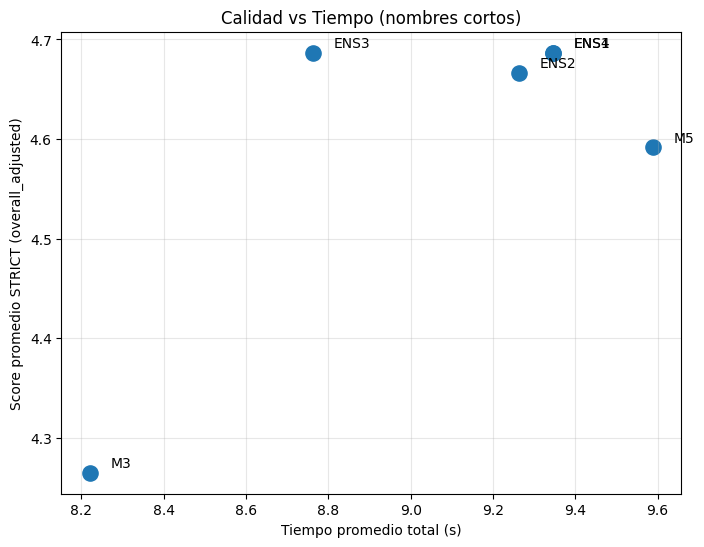

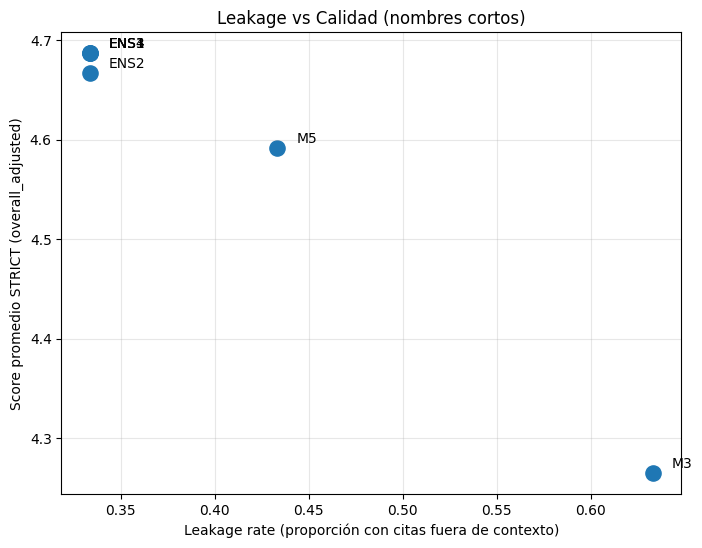

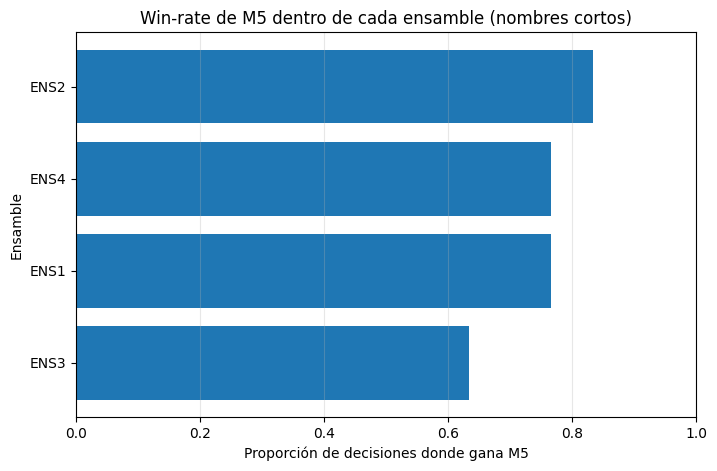

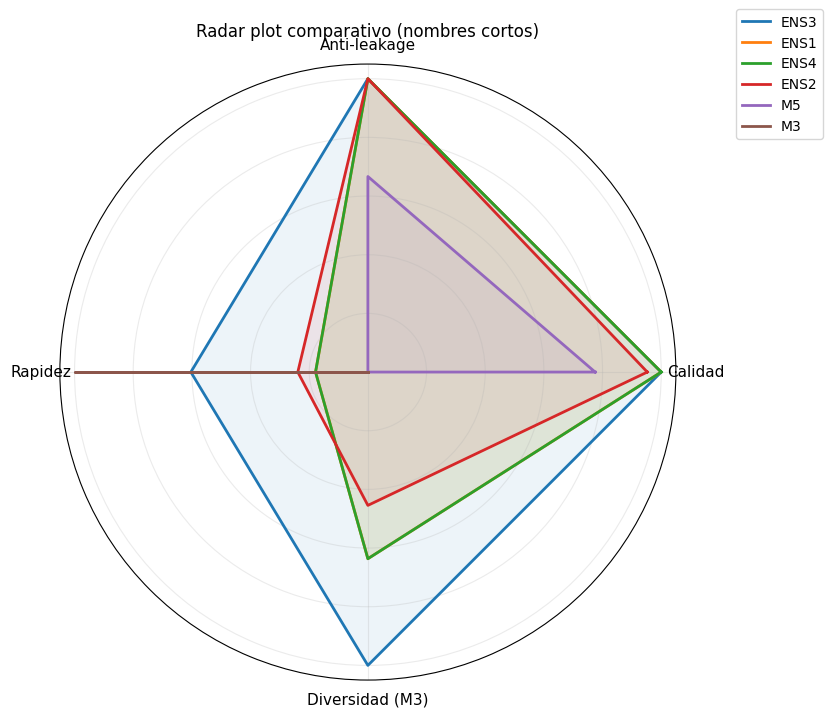

In [24]:
# ==========================================
# PARTE 7 - Visualizaciones (nombres cortos + tabla índice)
# ==========================================

# Este bloque:
# 1) Crea una tabla índice (código corto -> nombre completo)
# 2) Genera 3 gráficas limpias (una tras otra)
# 3) Genera un útil Radar plot comparativo

import matplotlib.pyplot as plt

# ---------------------------
# 1) Mapeo a nombres cortos
# ---------------------------
SHORT_MAP = {
    "ENS1_VOTING_STRICT (M5 vs M3)": "ENS1",
    "ENS2_VOTING_MIN_LEAKAGE (M5 vs M3)": "ENS2",
    "ENS3_BLEND_WEIGHTED (alpha=0.35, beta=0.02)": "ENS3",
    "ENS4_STACKING_BY_CATEGORY": "ENS4",
    "M5_DENSE_OAI_RAG": "M5",
    "M3_DENSE_ST_RAG": "M3",
}

comparison_plot = comparison.copy()
comparison_plot["short_code"] = comparison_plot["model"].map(SHORT_MAP).fillna(comparison_plot["model"])

# Tabla índice (para el doctor)
index_table = (comparison_plot[["short_code", "model"]]
               .drop_duplicates()
               .sort_values("short_code")
               .reset_index(drop=True))

print("Índice de nombres (código corto -> nombre completo):")
display(index_table)

# ---------------------------------------------------------
# Helper: anotación simple sin encimar
# ---------------------------------------------------------
def annotate_points(ax, x, y, labels, dx=0.01, dy=0.01):
    for xi, yi, lab in zip(x, y, labels):
        ax.annotate(str(lab), (xi, yi), xytext=(xi + dx, yi + dy),
                    textcoords="data", fontsize=10)

# Filtrar solo los 6 que queremos
keep_codes = {"ENS1", "ENS2", "ENS3", "ENS4", "M3", "M5"}
plot_df = comparison_plot[comparison_plot["short_code"].isin(keep_codes)].copy()

# Orden sugerido para lectura
order = ["ENS3", "ENS1", "ENS4", "ENS2", "M5", "M3"]
plot_df["order"] = plot_df["short_code"].apply(lambda x: order.index(x) if x in order else 999)
plot_df = plot_df.sort_values("order")

# =========================================================
# 2) Tres gráficas seguidas
# =========================================================

# --------
# Figura 1: Calidad vs Tiempo
# --------
plt.figure(figsize=(8, 6))
x = plot_df["total_time_mean"].astype(float).values
y = plot_df["judge_overall_adj_mean"].astype(float).values
labels = plot_df["short_code"].values

plt.scatter(x, y, s=120)
plt.xlabel("Tiempo promedio total (s)")
plt.ylabel("Score promedio STRICT (overall_adjusted)")
plt.title("Calidad vs Tiempo (nombres cortos)")
plt.grid(True, alpha=0.3)
annotate_points(plt.gca(), x, y, labels, dx=0.05, dy=0.005)
plt.show()

# --------
# Figura 2: Leakage vs Calidad
# --------
plt.figure(figsize=(8, 6))
plot_df2 = plot_df.dropna(subset=["leakage_rate_mean"]).copy()
x2 = plot_df2["leakage_rate_mean"].astype(float).values
y2 = plot_df2["judge_overall_adj_mean"].astype(float).values
labels2 = plot_df2["short_code"].values

plt.scatter(x2, y2, s=120)
plt.xlabel("Leakage rate (proporción con citas fuera de contexto)")
plt.ylabel("Score promedio STRICT (overall_adjusted)")
plt.title("Leakage vs Calidad (nombres cortos)")
plt.grid(True, alpha=0.3)
annotate_points(plt.gca(), x2, y2, labels2, dx=0.01, dy=0.005)
plt.show()

# --------
# Figura 3: Win-rate de M5 (solo ensambles)
# --------
plt.figure(figsize=(8, 5))
ens_only = plot_df[plot_df["short_code"].str.contains("ENS")].copy()
ens_only = ens_only.dropna(subset=["m5_win_rate"])

plt.barh(ens_only["short_code"], ens_only["m5_win_rate"].astype(float))
plt.xlabel("Proporción de decisiones donde gana M5")
plt.ylabel("Ensamble")
plt.title("Win-rate de M5 dentro de cada ensamble (nombres cortos)")
plt.grid(True, axis="x", alpha=0.3)
plt.xlim(0, 1)
plt.show()

# =========================================================
# 3) Radar plot comparativo (trade-offs multi-métrica)
# =========================================================
# ¿Qué es? Un gráfico tipo “telaraña” que compara varias métricas a la vez.
# Normalizamos todo a 0–1 donde "más alto = mejor":
# - Calidad: score_norm
# - Anti-leakage: 1 - leakage_norm
# - Rapidez: 1 - time_norm
# - Diversidad: m3_win_rate_norm (para ensambles; 0 para modelos individuales)

radar_df = plot_df.copy()

def minmax(series):
    s = series.astype(float)
    mn, mx = np.nanmin(s), np.nanmax(s)
    if np.isnan(mn) or np.isnan(mx) or np.isclose(mx - mn, 0):
        return np.zeros_like(s)
    return (s - mn) / (mx - mn)

radar_df["score_norm"] = minmax(radar_df["judge_overall_adj_mean"])
radar_df["leak_inv_norm"] = 1.0 - minmax(radar_df["leakage_rate_mean"].fillna(radar_df["leakage_rate_mean"].mean()))
radar_df["time_inv_norm"] = 1.0 - minmax(radar_df["total_time_mean"])

radar_df["m3_win_rate_filled"] = radar_df["m3_win_rate"].fillna(0.0)
radar_df["diversity_norm"] = minmax(radar_df["m3_win_rate_filled"])

metrics = ["score_norm", "leak_inv_norm", "time_inv_norm", "diversity_norm"]
metric_labels = ["Calidad", "Anti-leakage", "Rapidez", "Diversidad (M3)"]

N = len(metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
ax.set_title("Radar plot comparativo (nombres cortos)", pad=20)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_yticklabels([])
ax.grid(True, alpha=0.25)

for _, r in radar_df.iterrows():
    values = [float(r[m]) for m in metrics]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=r["short_code"])
    ax.fill(angles, values, alpha=0.08)

ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10))
plt.show()

### Interpretación (Análisis gráfico)

El análisis visual confirma los resultados numéricos:

- ENS3 se ubica en la frontera de Pareto calidad–tiempo.
- ENS1 y ENS4 presentan comportamiento prácticamente idéntico.
- ENS2 prioriza leakage pero no mejora significativamente la calidad.
- M5 y M3 individuales son superados consistentemente por los ensambles.

El radar plot evidencia que ENS3 presenta el mejor balance multiobjetivo entre:

- Calidad (STRICT)
- Control de leakage
- Rapidez
- Diversidad de decisiones

Por tanto, **ENS3 representa la opción más robusta para el sistema final LUMINA.**

---

> *"El que habla la verdad da un testimonio justo, pero el testigo falso dice mentiras. Hay quienes hablan sin pensar y sus palabras hieren como espadas, pero la lengua de los sabios trae sanidad."*
>
> — Proverbios 12:17-18

---

# **PARTE 8 – Selección del Modelo Final**

Con base en la evaluación cuantitativa y el análisis visual comparativo, se procede a seleccionar el modelo final que será integrado como arquitectura definitiva del sistema LUMINA.

### Modelo seleccionado: **ENS3_BLEND_WEIGHTED**

Justificación técnica:

- Máximo score promedio STRICT (4.69).
- Leakage controlado (0.33).
- Menor tiempo promedio entre los modelos de mayor calidad.
- Balance multiobjetivo comprobado.
- Distribución más equilibrada entre submodelos M5 y M3.

Desde una perspectiva CRISP-ML(Q), ENS3 representa la mejor solución en términos de desempeño global y robustez operacional.

## Conexión con CRISP-ML(Q)

Este trabajo se ubica principalmente en la fase de:

**Modeling + Evaluation (CRISP-ML(Q))**

Se realizaron:

- Optimización individual de modelos (Avance 4).
- Construcción de ensambles heterogéneos.
- Evaluación bajo esquema STRICT con penalización de leakage.
- Comparación multiobjetivo (calidad, trazabilidad, latencia).

La selección final del modelo se realizó con base en evidencia empírica cuantitativa y análisis gráfico, alineado con principios de evaluación rigurosa en sistemas de IA aplicada.

---

> *“Y dediqué mi corazón a inquirir y a explorar con sabiduría todo lo que se hace bajo el cielo…”*
>
> Eclesiastés 1:13 –

---